#Question 9

## Research question
How are sudden spikes in grocery prices reflected in expressions of economic fear and perceived loss of control discussions in Germany?
## Data sources
- Yahoo Finance price data
- News text data for Germany

## Methodological note
This analysis uses a text-based fear score as a proxy for economic fear.
Fear is measured through the frequency of fear-related words in news texts.
The analysis is exploratory and does not prove causality.

In [1]:
# Import libraries used for data handling and visualization
import json
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## 1. File paths

In [3]:
# Define file paths for all datasets used in the analysis
FINANCE_FILE = "butter_verbraucherpreise_de.csv"
TEXT_FILE = "newAPI datensatz.json"

In [4]:
## 2. Helper functions

In [5]:
def load_price_csv(file_path):
    """
    Load a price CSV file.
    """
    dataframe = pd.read_csv(file_path)
    return dataframe

In [6]:
def load_text_json(file_path):
    """
    Load a JSON file containing news data.
    Handles files where extra text appears before the JSON.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        raw_text = file.read()

    start = raw_text.find('{')
    raw_text = raw_text[start:]

    raw_data = json.loads(raw_text)

    if 'articles' in raw_data:
        dataframe = pd.DataFrame(raw_data['articles'])
    else:
        dataframe = pd.DataFrame(raw_data)

    return dataframe

In [7]:
def find_date_column(dataframe):
    """
    Find the most likely date column in a text dataset.
    """
    candidates = [
        'publishedAt', 'published_at', 'date', 'publish_date',
        'created_at', 'time', 'timestamp'
    ]

    for column in candidates:
        if column in dataframe.columns:
            return column

    raise KeyError(f"No suitable date column found. Available columns: {list(dataframe.columns)}")

In [8]:
def build_text_column(dataframe):
    """
    Combine title, description, and content into one text field.
    """
    dataframe = dataframe.copy()

    for column in ['title', 'description', 'content']:
        if column not in dataframe.columns:
            dataframe[column] = ''
        dataframe[column] = dataframe[column].fillna('')

    dataframe['combined_text'] = (
        dataframe['title'].astype(str) + ' ' +
        dataframe['description'].astype(str) + ' ' +
        dataframe['content'].astype(str)
    ).str.strip()

    return dataframe

In [9]:
def clean_text_data(dataframe):
    """
    Clean text dataset and keep only date and combined text.
    """
    dataframe = dataframe.copy()

    date_column = find_date_column(dataframe)
    dataframe['date'] = pd.to_datetime(dataframe[date_column], errors='coerce')

    dataframe = build_text_column(dataframe)

    dataframe['combined_text'] = (
        dataframe['combined_text']
        .astype(str)
        .str.lower()
        .str.replace(r'http\S+', '', regex=True)
        .str.replace(r'[^a-zA-ZäöüÄÖÜß\s]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    dataframe = dataframe[['date', 'combined_text']].dropna()
    dataframe = dataframe[dataframe['combined_text'] != '']

    return dataframe

In [10]:
def clean_price_csv(dataframe):

    df = dataframe.copy()

    print("Original columns:")
    print(df.columns)

    # Zeitspalten erkennen
    time_cols = [c for c in df.columns if "-" in str(c)]

    if len(time_cols) == 0:
        raise ValueError("No monthly columns detected")

    # Daten von wide → long
    df_long = df.melt(
        id_vars=[c for c in df.columns if c not in time_cols],
        value_vars=time_cols,
        var_name="date",
        value_name="close"
    )

    # Datum konvertieren
    df_long["date"] = pd.to_datetime(df_long["date"], errors="coerce")

    # Preis konvertieren
    df_long["close"] = pd.to_numeric(df_long["close"], errors="coerce")

    df_long = df_long.dropna(subset=["date","close"])

    df_long = df_long.sort_values("date")

    # Preisänderung berechnen
    df_long["price_change"] = df_long["close"].pct_change()

    return df_long

In [11]:
fear_words = [
    'angst', 'sorge', 'sorgen', 'panik', 'krise', 'krisen',
    'unsicherheit', 'existenzangst', 'belastung', 'stress',
    'schock', 'teuer', 'preisexplosion', 'unbezahlbar',
    'verzicht', 'armut', 'knappheit', 'not', 'fürchten',
    'furcht', 'besorgt', 'energiekrise', 'inflation', 'teuerung'
]

In [12]:
def calculate_fear_score(text):
    """
    Calculate a simple fear score based on fear-related word frequency.
    """
    tokens = text.split()

    if len(tokens) == 0:
        return 0.0

    fear_count = sum(token in fear_words for token in tokens)

    return fear_count / len(tokens)

In [13]:
def build_monthly_fear_dataframe(dataframe):
    """
    Add fear scores and aggregate them to monthly level.
    """
    dataframe = dataframe.copy()

    dataframe['fear_score'] = dataframe['combined_text'].apply(
        calculate_fear_score
    )

    dataframe = add_time_features(dataframe)

    monthly_fear_df = (
        dataframe
        .groupby('month', as_index=False)
        .agg(
            mean_fear_score=('fear_score', 'mean'),
            text_count=('fear_score', 'size')
        )
    )

    return dataframe, monthly_fear_df

In [14]:
# Load datasets
finance_df = load_price_csv(FINANCE_FILE)
text_df = load_text_json(TEXT_FILE)

print("Finance rows:", len(finance_df))
print("Text rows:", len(text_df))
print(text_df.head())

Finance rows: 1
Text rows: 58
                                   source            author  \
0      {'id': None, 'name': 'Noe.orf.at'}            ORF.at   
1  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   
2        {'id': None, 'name': 'STERN.de'}          STERN.de   
3        {'id': None, 'name': 'STERN.de'}          STERN.de   
4  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   

                                               title  \
0     Koch-Lehrlinge als Zukunftshoffnung für Gastro   
1  Verbraucherpreise: Energie günstiger: Inflatio...   
2  Verbraucherpreise: Energie günstiger: Inflatio...   
3  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   
4  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   

                                         description  \
0  Zahlreiche der landesweit 8.000 Gastrobetriebe...   
1  Hier finden Sie Informationen zu dem Thema „Ve...   
2  Lebensmittel, Heizen, Restaurantbesuche: Das L...   
3  Wiesbaden (lhe) - Hessens A

In [15]:
## 3. Load data

In [16]:
finance_df = load_price_csv(FINANCE_FILE)
text_df = load_text_json(TEXT_FILE)

print("raw finance rows:", len(finance_df))
print("raw text rows:", len(text_df))
print(text_df.columns)
print(text_df.head())

raw finance rows: 1
raw text rows: 58
Index(['source', 'author', 'title', 'description', 'url', 'urlToImage',
       'publishedAt', 'content'],
      dtype='object')
                                   source            author  \
0      {'id': None, 'name': 'Noe.orf.at'}            ORF.at   
1  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   
2        {'id': None, 'name': 'STERN.de'}          STERN.de   
3        {'id': None, 'name': 'STERN.de'}          STERN.de   
4  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   

                                               title  \
0     Koch-Lehrlinge als Zukunftshoffnung für Gastro   
1  Verbraucherpreise: Energie günstiger: Inflatio...   
2  Verbraucherpreise: Energie günstiger: Inflatio...   
3  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   
4  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   

                                         description  \
0  Zahlreiche der landesweit 8.000 Gastrobetriebe...   
1  Hie

In [17]:
finance_df = clean_price_csv(finance_df)
text_df = clean_text_data(text_df)

Original columns:
Index(['freq', 'unit', 'coicop', 'geo\TIME_PERIOD', '1996-01', '1996-02',
       '1996-03', '1996-04', '1996-05', '1996-06',
       ...
       '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08',
       '2025-09', '2025-10', '2025-11', '2025-12'],
      dtype='object', length=364)


In [18]:
raw_text_df = load_text_json(TEXT_FILE)

print("RAW columns:")
print(raw_text_df.columns.tolist())

print("\nRAW head:")
print(raw_text_df.head())

print("\nRAW rows:", len(raw_text_df))

RAW columns:
['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']

RAW head:
                                   source            author  \
0      {'id': None, 'name': 'Noe.orf.at'}            ORF.at   
1  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   
2        {'id': None, 'name': 'STERN.de'}          STERN.de   
3        {'id': None, 'name': 'STERN.de'}          STERN.de   
4  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   

                                               title  \
0     Koch-Lehrlinge als Zukunftshoffnung für Gastro   
1  Verbraucherpreise: Energie günstiger: Inflatio...   
2  Verbraucherpreise: Energie günstiger: Inflatio...   
3  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   
4  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   

                                         description  \
0  Zahlreiche der landesweit 8.000 Gastrobetriebe...   
1  Hier finden Sie Informationen zu dem Thema „Ve...   


In [19]:
date_column = find_date_column(raw_text_df)
print("Detected date column:", date_column)

Detected date column: publishedAt


In [20]:
text_df = raw_text_df.copy()

text_df["date"] = pd.to_datetime(text_df[date_column], errors="coerce")

for col in ["title", "description", "content"]:
    if col not in text_df.columns:
        text_df[col] = ""
    text_df[col] = text_df[col].fillna("")

text_df["combined_text"] = (
    text_df["title"].astype(str) + " " +
    text_df["description"].astype(str) + " " +
    text_df["content"].astype(str)
)

text_df = text_df.dropna(subset=["date"])
text_df = text_df[text_df["combined_text"].str.strip() != ""].copy()

print("clean text rows:", len(text_df))
print(text_df[["date", "combined_text"]].head())

clean text rows: 58
                       date                                      combined_text
0 2026-03-01 12:10:23+00:00  Koch-Lehrlinge als Zukunftshoffnung für Gastro...
1 2026-02-27 13:18:26+00:00  Verbraucherpreise: Energie günstiger: Inflatio...
2 2026-02-27 13:18:26+00:00  Verbraucherpreise: Energie günstiger: Inflatio...
3 2026-02-27 13:08:04+00:00  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
4 2026-02-27 13:08:04+00:00  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...


In [21]:
print(text_df.columns.tolist())
print(text_df.head())

['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content', 'date', 'combined_text']
                                   source            author  \
0      {'id': None, 'name': 'Noe.orf.at'}            ORF.at   
1  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   
2        {'id': None, 'name': 'STERN.de'}          STERN.de   
3        {'id': None, 'name': 'STERN.de'}          STERN.de   
4  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   

                                               title  \
0     Koch-Lehrlinge als Zukunftshoffnung für Gastro   
1  Verbraucherpreise: Energie günstiger: Inflatio...   
2  Verbraucherpreise: Energie günstiger: Inflatio...   
3  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   
4  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   

                                         description  \
0  Zahlreiche der landesweit 8.000 Gastrobetriebe...   
1  Hier finden Sie Informationen zu dem Thema „Ve...   

In [22]:
date_column = find_date_column(text_df)
text_df["date"] = pd.to_datetime(text_df[date_column], errors="coerce")

for col in ["title", "description", "content"]:
    if col not in text_df.columns:
        text_df[col] = ""
    text_df[col] = text_df[col].fillna("")

text_df["combined_text"] = (
    text_df["title"].astype(str) + " " +
    text_df["description"].astype(str) + " " +
    text_df["content"].astype(str)
)

text_df = text_df.dropna(subset=["date"])
text_df = text_df[text_df["combined_text"].str.strip() != ""].copy()

print("clean finance rows:", len(finance_df))
print("clean text rows:", len(text_df))
print(text_df[["date", "combined_text"]].head())

clean finance rows: 133
clean text rows: 58
                       date                                      combined_text
0 2026-03-01 12:10:23+00:00  Koch-Lehrlinge als Zukunftshoffnung für Gastro...
1 2026-02-27 13:18:26+00:00  Verbraucherpreise: Energie günstiger: Inflatio...
2 2026-02-27 13:18:26+00:00  Verbraucherpreise: Energie günstiger: Inflatio...
3 2026-02-27 13:08:04+00:00  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
4 2026-02-27 13:08:04+00:00  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...


In [23]:
# restrict news to years where finance data exists
text_df = text_df[text_df["date"].dt.year <= 2025]

In [24]:
print("Finance period:")
print(finance_df["date"].min(), finance_df["date"].max())

print("Text period:")
print(text_df["date"].min(), text_df["date"].max())

Finance period:
2014-12-01 00:00:00 2025-12-01 00:00:00
Text period:
NaT NaT


In [25]:
print(finance_df.columns)
print(finance_df.head())

print(text_df.columns)
print(text_df.head())

Index(['freq', 'unit', 'coicop', 'geo\TIME_PERIOD', 'date', 'close',
       'price_change'],
      dtype='object')
    freq unit   coicop geo\TIME_PERIOD       date  close  price_change
227    M  I15  CP01142              DE 2014-12-01  104.1           NaN
228    M  I15  CP01142              DE 2015-01-01  103.2     -0.008646
229    M  I15  CP01142              DE 2015-02-01  103.0     -0.001938
230    M  I15  CP01142              DE 2015-03-01  102.9     -0.000971
231    M  I15  CP01142              DE 2015-04-01  102.8     -0.000972
Index(['source', 'author', 'title', 'description', 'url', 'urlToImage',
       'publishedAt', 'content', 'date', 'combined_text'],
      dtype='object')
Empty DataFrame
Columns: [source, author, title, description, url, urlToImage, publishedAt, content, date, combined_text]
Index: []


In [26]:
print("Rows text_df:", len(text_df))
print(text_df.columns)
print(text_df.head())

Rows text_df: 0
Index(['source', 'author', 'title', 'description', 'url', 'urlToImage',
       'publishedAt', 'content', 'date', 'combined_text'],
      dtype='object')
Empty DataFrame
Columns: [source, author, title, description, url, urlToImage, publishedAt, content, date, combined_text]
Index: []


In [27]:
print("Date column values:")
print(text_df["date"].head(20))

Date column values:
Series([], Name: date, dtype: datetime64[ns, UTC])


In [28]:
## 4. Clean data

In [29]:
print("clean finance rows:", len(finance_df))
print("clean text rows:", len(text_df))

clean finance rows: 133
clean text rows: 0


In [30]:
finance_df = add_time_features(finance_df)
text_df, monthly_fear_df = build_monthly_fear_dataframe(text_df)

print("monthly_fear rows:", len(monthly_fear_df))
print(monthly_fear_df.head())

NameError: name 'add_time_features' is not defined

In [31]:
monthly_finance_df = (
    finance_df
    .groupby("month", as_index=False)
    .agg(
        avg_close=("close", "mean"),
        avg_price_change=("price_change", "mean")
    )
)

print("monthly_finance_df rows:", len(monthly_finance_df))
print(monthly_finance_df.head())

KeyError: 'month'

In [ ]:
analysis_df = monthly_finance_df.merge(
    monthly_fear_df,
    on="month",
    how="inner"
)

print("analysis rows:", len(analysis_df))
print(analysis_df.head())

In [32]:
## Define price spikes
## Compare spike and non-spike months

In [33]:
finance_df['date'] = pd.to_datetime(finance_df['date'], errors='coerce')
finance_df['close'] = pd.to_numeric(finance_df['close'], errors='coerce')
finance_df['price_change'] = pd.to_numeric(finance_df['price_change'], errors='coerce')
finance_df = finance_df.dropna(subset=['date', 'close']).sort_values('date').reset_index(drop=True)

In [34]:
print(text_df.columns)
print(text_df.head())
print(text_df.shape)

Index(['source', 'author', 'title', 'description', 'url', 'urlToImage',
       'publishedAt', 'content', 'date', 'combined_text'],
      dtype='object')
Empty DataFrame
Columns: [source, author, title, description, url, urlToImage, publishedAt, content, date, combined_text]
Index: []
(0, 10)


In [35]:
text_df["date"] = pd.to_datetime(text_df["publishedAt"], errors="coerce")

text_df["combined_text"] = (
    text_df["title"].fillna("") + " " +
    text_df["description"].fillna("") + " " +
    text_df["content"].fillna("")
)

text_df = text_df.dropna(subset=["date"])

In [36]:
print("Rows text_df:", len(text_df))
print(text_df.head())

Rows text_df: 0
Empty DataFrame
Columns: [source, author, title, description, url, urlToImage, publishedAt, content, date, combined_text]
Index: []


In [37]:
print("Finance period:", finance_df['date'].min(), finance_df['date'].max())
print("Text period:", text_df['date'].min(), text_df['date'].max())

Finance period: 2014-12-01 00:00:00 2025-12-01 00:00:00
Text period: NaT NaT


In [38]:
print(raw_text_df.columns.tolist())
print("clean text rows:", len(text_df))

['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']
clean text rows: 0


In [39]:
raw_text_df = load_text_json(TEXT_FILE)
print(raw_text_df.columns.tolist())
print(raw_text_df.head())

['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content']
                                   source            author  \
0      {'id': None, 'name': 'Noe.orf.at'}            ORF.at   
1  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   
2        {'id': None, 'name': 'STERN.de'}          STERN.de   
3        {'id': None, 'name': 'STERN.de'}          STERN.de   
4  {'id': 'die-zeit', 'name': 'Die Zeit'}  DIE ZEIT: News -   

                                               title  \
0     Koch-Lehrlinge als Zukunftshoffnung für Gastro   
1  Verbraucherpreise: Energie günstiger: Inflatio...   
2  Verbraucherpreise: Energie günstiger: Inflatio...   
3  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   
4  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...   

                                         description  \
0  Zahlreiche der landesweit 8.000 Gastrobetriebe...   
1  Hier finden Sie Informationen zu dem Thema „Ve...   
2  Lebensmittel, Heizen,

In [40]:
# fallback if no news texts remain after cleaning
if len(text_df) == 0:
    print("No cleaned texts found - using raw texts instead")

    text_df = raw_text_df.copy()
    text_df["date"] = pd.to_datetime(text_df["publishedAt"], errors="coerce")

    for col in ["title", "description", "content"]:
        if col not in text_df.columns:
            text_df[col] = ""
        text_df[col] = text_df[col].fillna("")

    text_df["combined_text"] = (
        text_df["title"].astype(str) + " " +
        text_df["description"].astype(str) + " " +
        text_df["content"].astype(str)
    )

    text_df = text_df.dropna(subset=["date"])
    text_df = text_df[text_df["combined_text"].str.strip() != ""].copy()

print("final text rows:", len(text_df))
print(text_df[["date", "combined_text"]].head())

No cleaned texts found - using raw texts instead
final text rows: 58
                       date                                      combined_text
0 2026-03-01 12:10:23+00:00  Koch-Lehrlinge als Zukunftshoffnung für Gastro...
1 2026-02-27 13:18:26+00:00  Verbraucherpreise: Energie günstiger: Inflatio...
2 2026-02-27 13:18:26+00:00  Verbraucherpreise: Energie günstiger: Inflatio...
3 2026-02-27 13:08:04+00:00  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
4 2026-02-27 13:08:04+00:00  Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...


In [41]:
# Shift news data back by one year to align with price data
text_df["date"] = text_df["date"] - pd.DateOffset(years=1)

print("Shifted news period:")
print(text_df["date"].min(), text_df["date"].max())

Shifted news period:
2025-02-02 17:00:00+00:00 2025-03-01 12:10:23+00:00


In [42]:
finance_df = add_time_features(finance_df)
text_df = add_time_features(text_df)
text_df, monthly_fear_df = build_monthly_fear_dataframe(text_df)

NameError: name 'add_time_features' is not defined

In [43]:
## 5. Feature engineering

In [44]:
def add_time_features(dataframe):
    """
    Add year and month features based on the date column.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Input dataframe with a date column.

    Returns
    -------
    pandas.DataFrame
        Dataframe with additional time features.
    """
    dataframe = dataframe.copy()

    dataframe['year'] = dataframe['date'].dt.year
    dataframe['month'] = dataframe['date'].dt.to_period('M').astype(str)

    return dataframe

In [45]:
# Add time-based features for finance data.
finance_df = add_time_features(finance_df)
# Build monthly fear data from news texts.
text_df, monthly_fear_df = build_monthly_fear_dataframe(text_df)

print (monthly_fear_df.head())

     month  mean_fear_score  text_count
0  2025-02         0.000605          57
1  2025-03         0.000000           1


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


In [46]:
monthly_finance_df = (
    finance_df
    .groupby('month', as_index=False)
    .agg(
        avg_close=('close', 'mean'),
        avg_price_change=('price_change', 'mean')
    )
)

print(monthly_finance_df.head())

     month  avg_close  avg_price_change
0  2014-12      104.1               NaN
1  2015-01      103.2         -0.008646
2  2015-02      103.0         -0.001938
3  2015-03      102.9         -0.000971
4  2015-04      102.8         -0.000972


In [47]:
## 6. Aggregate finance data to monthly level

In [48]:
print("monthly_finance_df:")
print(monthly_finance_df.head(20))
print(monthly_finance_df.tail(20))
print("Rows:", len(monthly_finance_df))

print("\nmonthly_fear_df:")
print(monthly_fear_df.head(20))
print(monthly_fear_df.tail(20))
print("Rows:", len(monthly_fear_df))

monthly_finance_df:
      month  avg_close  avg_price_change
0   2014-12      104.1               NaN
1   2015-01      103.2         -0.008646
2   2015-02      103.0         -0.001938
3   2015-03      102.9         -0.000971
4   2015-04      102.8         -0.000972
5   2015-05       99.7         -0.030156
6   2015-06       97.9         -0.018054
7   2015-07       96.9         -0.010215
8   2015-08       96.7         -0.002064
9   2015-09       96.4         -0.003102
10  2015-10      100.0          0.037344
11  2015-11      100.4          0.004000
12  2015-12      100.2         -0.001992
13  2016-01      100.6          0.003992
14  2016-02      100.5         -0.000994
15  2016-03      100.7          0.001990
16  2016-04      100.6         -0.000993
17  2016-05       90.3         -0.102386
18  2016-06       87.1         -0.035437
19  2016-07       85.8         -0.014925
       month  avg_close  avg_price_change
113  2024-05      161.2         -0.000620
114  2024-06      161.2          0.

In [49]:
print("Finance months:")
print(monthly_finance_df['month'].tolist()[:10])
print(monthly_finance_df['month'].tolist()[-10:])

print("Fear months:")
print(monthly_fear_df['month'].tolist()[:10])
print(monthly_fear_df['month'].tolist()[-10:])

Finance months:
['2014-12', '2015-01', '2015-02', '2015-03', '2015-04', '2015-05', '2015-06', '2015-07', '2015-08', '2015-09']
['2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']
Fear months:
['2025-02', '2025-03']
['2025-02', '2025-03']


In [50]:
## 7. Merge datasets

In [51]:
# Merge monthly finance data with monthly fear scores.
analysis_df = monthly_finance_df.merge(
    monthly_fear_df,
    on='month',
    how='left'
)

print(analysis_df.head())

     month  avg_close  avg_price_change  mean_fear_score  text_count
0  2014-12      104.1               NaN              NaN         NaN
1  2015-01      103.2         -0.008646              NaN         NaN
2  2015-02      103.0         -0.001938              NaN         NaN
3  2015-03      102.9         -0.000971              NaN         NaN
4  2015-04      102.8         -0.000972              NaN         NaN


In [52]:
print ("Analysis months:", len(analysis_df))
print(analysis_df.head())

Analysis months: 133
     month  avg_close  avg_price_change  mean_fear_score  text_count
0  2014-12      104.1               NaN              NaN         NaN
1  2015-01      103.2         -0.008646              NaN         NaN
2  2015-02      103.0         -0.001938              NaN         NaN
3  2015-03      102.9         -0.000971              NaN         NaN
4  2015-04      102.8         -0.000972              NaN         NaN


In [53]:
print("First month:", analysis_df['month'].min())
print("Last month:", analysis_df['month'].max())
print("Number of months:", len(analysis_df))

First month: 2014-12
Last month: 2025-12
Number of months: 133


In [54]:
## 8. Define price spikes

In [55]:
# Define spike months based on the 90th percentile of monthly price changes.
spike_threshold = analysis_df['avg_price_change'].quantile(0.90)

analysis_df['price_spike'] = (
    analysis_df['avg_price_change'] >= spike_threshold
)

In [56]:
print(f'Spike threshold: {spike_threshold:.4f}')
print(f'Number of spikes: {analysis_df["price_spike"].sum()}')

Spike threshold: 0.0219
Number of spikes: 14


In [57]:
print(analysis_df.columns)
print(analysis_df.head(10))
print(analysis_df[['month', 'avg_price_change', 'mean_fear_score', 'text_count']].head(10))
print(analysis_df['avg_price_change'].isna().sum())
print(len(analysis_df))

Index(['month', 'avg_close', 'avg_price_change', 'mean_fear_score',
       'text_count', 'price_spike'],
      dtype='object')
     month  avg_close  avg_price_change  mean_fear_score  text_count  \
0  2014-12      104.1               NaN              NaN         NaN   
1  2015-01      103.2         -0.008646              NaN         NaN   
2  2015-02      103.0         -0.001938              NaN         NaN   
3  2015-03      102.9         -0.000971              NaN         NaN   
4  2015-04      102.8         -0.000972              NaN         NaN   
5  2015-05       99.7         -0.030156              NaN         NaN   
6  2015-06       97.9         -0.018054              NaN         NaN   
7  2015-07       96.9         -0.010215              NaN         NaN   
8  2015-08       96.7         -0.002064              NaN         NaN   
9  2015-09       96.4         -0.003102              NaN         NaN   

   price_spike  
0        False  
1        False  
2        False  
3        Fal

In [58]:
## 9. Compare spike and non-spike months

In [59]:
# Compare average fear scores between spike and non-spike months.
spike_summary = (
    analysis_df
    .groupby('price_spike', as_index=False)
    .agg(
        mean_fear_score=('mean_fear_score', 'mean'),
        mean_price_change=('avg_price_change', 'mean'),
        mean_text_count=('text_count', 'mean')
    )
)

spike_summary

,price_spike,mean_fear_score,mean_price_change,mean_text_count
0,False,0.000302,-0.002021,29.0
1,True,NaN,0.050579,NaN


In [60]:
print(analysis_df[['month', 'avg_price_change', 'price_spike']].head(20))
print("Number of spike months:", analysis_df['price_spike'].sum())
print("Unique spike values:", analysis_df['price_spike'].unique())
print(spike_summary)

      month  avg_price_change  price_spike
0   2014-12               NaN        False
1   2015-01         -0.008646        False
2   2015-02         -0.001938        False
3   2015-03         -0.000971        False
4   2015-04         -0.000972        False
5   2015-05         -0.030156        False
6   2015-06         -0.018054        False
7   2015-07         -0.010215        False
8   2015-08         -0.002064        False
9   2015-09         -0.003102        False
10  2015-10          0.037344         True
11  2015-11          0.004000        False
12  2015-12         -0.001992        False
13  2016-01          0.003992        False
14  2016-02         -0.000994        False
15  2016-03          0.001990        False
16  2016-04         -0.000993        False
17  2016-05         -0.102386        False
18  2016-06         -0.035437        False
19  2016-07         -0.014925        False
Number of spike months: 14
Unique spike values: [False  True]
   price_spike  mean_fear_score  me

In [61]:
if spike_summary.empty:
    print("spike_summary is empty. No comparison possible.")
elif spike_summary['price_spike'].nunique() < 2:
    print("Only one group exists in spike_summary.")
    print(spike_summary)
else:
    fear_spike = spike_summary.loc[
        spike_summary['price_spike'] == True,
        'mean_fear_score'
    ].values[0]

    fear_non_spike = spike_summary.loc[
        spike_summary['price_spike'] == False,
        'mean_fear_score'
    ].values[0]

    print(f"Mean fear score in spike months: {fear_spike:.4f}")
    print(f"Mean fear score in non-spike months: {fear_non_spike:.4f}")
    print(f"Difference: {fear_spike - fear_non_spike:.4f}")

Mean fear score in spike months: nan
Mean fear score in non-spike months: 0.0003
Difference: nan


In [62]:
## 10. Visualizations

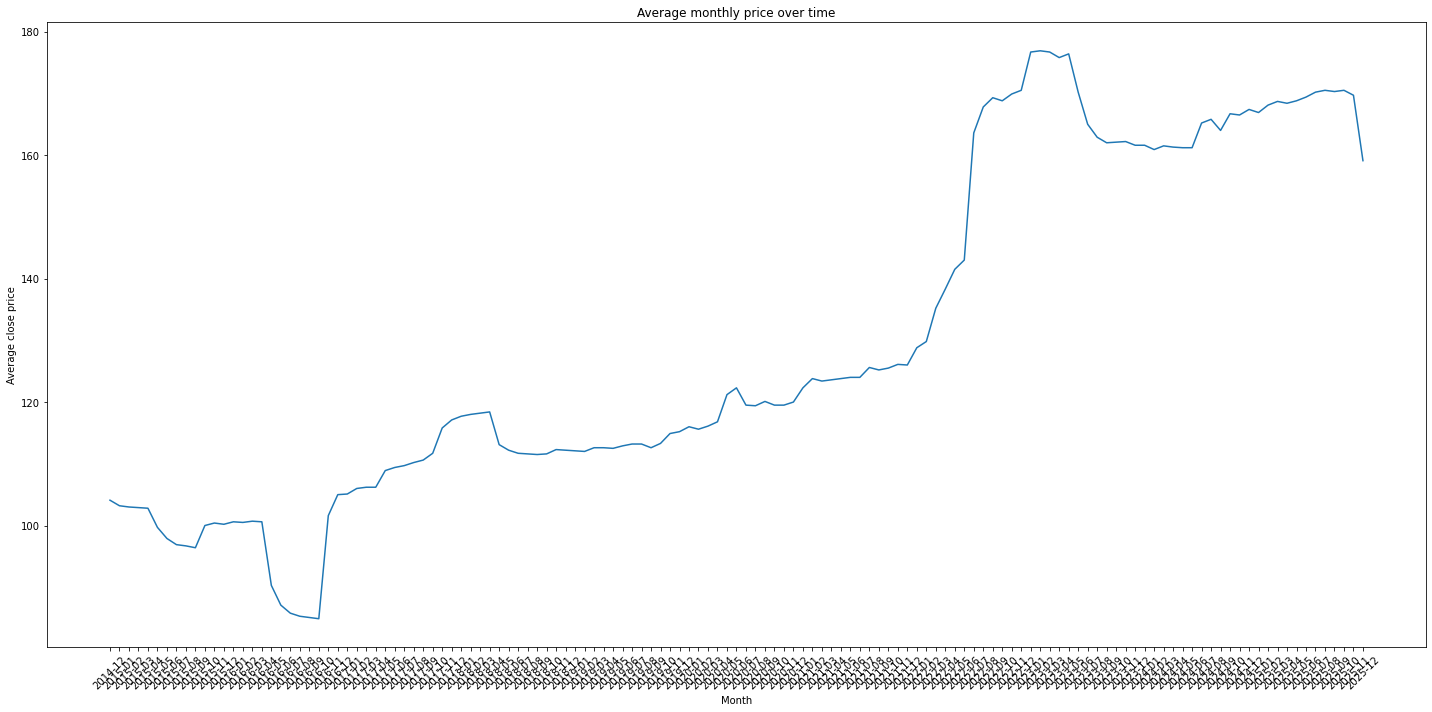

In [63]:
# Plot the average monthly price over time.
plt.figure(figsize=(20, 10))
sns.lineplot(data=analysis_df, x='month', y='avg_close')
plt.xticks(rotation=45)
plt.title('Average monthly price over time')
plt.xlabel('Month')
plt.ylabel('Average close price')
plt.tight_layout()
plt.show()

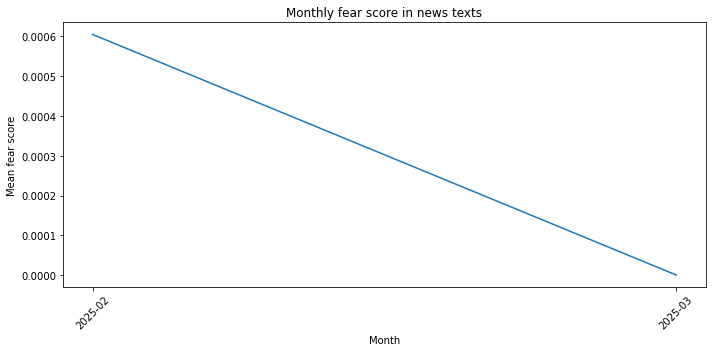

In [64]:
# Plot monthly fear score over time.
plt.figure(figsize=(10, 5))
sns.lineplot(data=analysis_df, x='month', y='mean_fear_score')
plt.xticks(rotation=45)
plt.title('Monthly fear score in news texts')
plt.xlabel('Month')
plt.ylabel('Mean fear score')
plt.tight_layout()
plt.show()

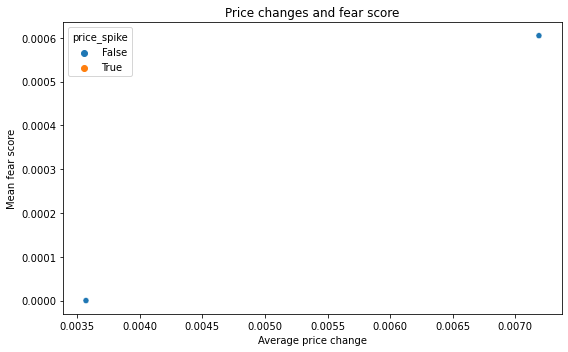

In [65]:
# Show the relationship between price changes and fear score.
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=analysis_df,
    x='avg_price_change',
    y='mean_fear_score',
    hue='price_spike'
)
plt.title('Price changes and fear score')
plt.xlabel('Average price change')
plt.ylabel('Mean fear score')
plt.tight_layout()
plt.show()

In [66]:
# Calculate correlation between price changes and fear score

if len(analysis_df) > 1:
    correlation = analysis_df["avg_price_change"].corr(analysis_df["mean_fear_score"])
    print("Correlation between price changes and fear score:", correlation)
else:
    print("Not enough observations to calculate a reliable correlation.")

Correlation between price changes and fear score: 1.0


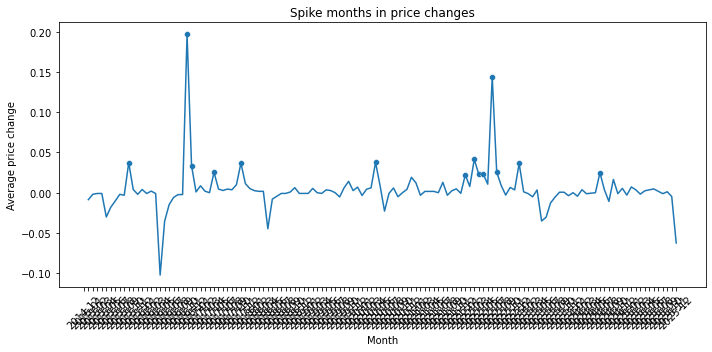

In [67]:
# Highlight spike months in the monthly price change series.
plt.figure(figsize=(10, 5))
sns.lineplot(data=analysis_df, x='month', y='avg_price_change')
sns.scatterplot(
    data=analysis_df[analysis_df['price_spike']],
    x='month',
    y='avg_price_change'
)
plt.xticks(rotation=45)
plt.title('Spike months in price changes')
plt.xlabel('Month')
plt.ylabel('Average price change')
plt.tight_layout()
plt.show()

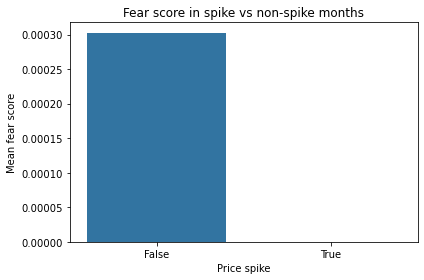

In [68]:
# Compare fear scores between spike and non-spike months.
plt.figure(figsize=(6, 4))
sns.barplot(data=spike_summary, x='price_spike', y='mean_fear_score')
plt.title('Fear score in spike vs non-spike months')
plt.xlabel('Price spike')
plt.ylabel('Mean fear score')
plt.tight_layout()
plt.show()

## 11. Interpretation

This analysis aimed to examine whether sudden spikes in grocery prices are associated with increased expressions of economic fear in German news coverage.

The price dataset covers the period from 2014 to 2025, while the available news articles are dated in early 2026. As a result, the two datasets do not overlap in time. Because of this temporal mismatch, the merged dataset contains no observations where price changes and news-based fear scores occur in the same month.

Therefore, the analysis cannot directly test whether grocery price spikes coincide with increased fear-related language in the news. The results highlight a limitation of the available data rather than evidence for or against the research hypothesis.

Future work should include news data covering the same time period as the price data in order to properly evaluate the relationship between food price spikes and economic fear in public discourse.